# 第 2 週:強形式與弱形式——從統御方程式到變分原理的正式推導

**課程:計算力學方法論——驗證、確效與跨平台交叉比對**

第 1 週我們**先有答案**(解析解),再用四種方法去驗證。
這一週反過來:**先不假設答案存在**,從物理平衡出發,一步步正式推導出強形式與弱形式,
並證明(在解夠光滑的前提下)兩者等價。

這週還做一件第 1 週沒做的事:把桿件的 $EA$ **從常數推廣成 $x$ 的函數**。
你會看到,一旦 $EA$ 不是常數,第 1 週觀察到的「節點精確性」(有限元素節點解與解析解完全相等)
會馬上失效——這不是巧合,是第 6 週要正式討論的現象的第一個具體例子。

## 1. 從物理平衡出發:強形式的一般化描述

考慮一根長度 $L$ 的桿件,截面軸向勁度為 $EA(x)$(允許沿長度變化),
承受分布軸力 $f(x)$(也允許沿長度變化)。取一段微元 $[x, x+dx]$ 做軸力平衡:

$$N(x+dx) - N(x) + f(x)\,dx = 0 \quad\Longrightarrow\quad \frac{dN}{dx} = -f(x)$$

其中內力 $N(x) = EA(x)\,u'(x)$(虎克定律)。代入得**統御微分方程(強形式)**:

$$-\frac{d}{dx}\!\left(EA(x)\,u'(x)\right) = f(x), \qquad 0<x<L$$

邊界條件分兩類:

- **本質邊界條件(essential / Dirichlet)**:直接指定位移,例如 $u(0)=0$
- **自然邊界條件(natural / Neumann)**:指定力,例如 $EA(L)\,u'(L) = \bar{N}$(本例取自由端 $\bar N=0$)

這個方程式**要求 $u$ 二階可微、$EA(x)$ 至少一階可微**——這個「解要夠光滑」的要求,
正是弱形式想要放寬的東西。

## 2. 動機:為什麼要弱形式?

強形式對解的光滑度要求很高。實務上常常遇到:

- $EA(x)$ 在材料介面處不連續(例如兩種材料拼接的複合桿件)
- 荷重 $f(x)$ 本身是分段函數,甚至包含集中力(狄拉克函數)
- 我們其實只想要一個「夠好」的近似解,不需要處處二階可微

**加權殘值法(Method of Weighted Residuals)** 的想法是:與其要求 $-\left(EAu'\right)' - f$
處處恰好為零,不如只要求它與一組「測試函數」$v$ 的加權平均(內積)為零:

$$\int_0^L \Big[-\big(EA\,u'\big)' - f\Big]\,v\,dx = 0, \qquad \forall v \in V$$

其中 $V$ 是滿足其次本質邊界條件的測試函數空間($v(0)=0$,因為 $u(0)=0$ 已經是已知量,
測試方向不需要在那裡變化)。這個式子還是要求 $u$ 二階可微(裡面有 $u''$),還沒有真正降低要求——
下一步的分部積分才是關鍵。

## 3. 分部積分:弱形式的正式推導

對加權殘值式的第一項做分部積分:

$$-\int_0^L \big(EA\,u'\big)' v\,dx
= -\Big[EA\,u'\,v\Big]_0^L + \int_0^L EA\,u'\,v'\,dx$$

邊界項展開:

$$-\Big[EA\,u'\,v\Big]_0^L = -EA(L)u'(L)v(L) + EA(0)u'(0)v(0)$$

因為測試函數要求 $v(0)=0$(本質邊界條件的位置,測試函數在那裡歸零),第二項自動消失。
第一項代入自然邊界條件 $EA(L)u'(L)=0$(自由端力邊界條件),也自動消失。

**這就是「自然邊界條件」這個名字的由來**——它不需要額外強加,分部積分後自動滿足在弱形式的邊界項裡;
真正需要「強加」的只有本質邊界條件(透過限制 $u,v$ 所在的函數空間)。

整理後得到**弱形式(變分形式)**:

> 求 $u$,使得 $u(0)=0$,且對所有滿足 $v(0)=0$ 的 $v$,
> $$\int_0^L EA(x)\,u'(x)\,v'(x)\,dx = \int_0^L f(x)\,v(x)\,dx$$

注意:這個式子只要求 $u,v$ **一階**可微(而且允許在有限個點不連續,只要積分存在),
比強形式的二階要求弱很多——這正是「弱形式」名字的來源。

## 4. 弱形式的數學結構:雙線性形式與線性泛函

把弱形式寫成抽象記號,會發現它正好對應到 scikit-fem 的 `@BilinearForm` / `@LinearForm` 裝飾器:

$$a(u,v) = \int_0^L EA\,u'v'\,dx \qquad\text{(雙線性形式,對應 `a_form`)}$$

$$L(v) = \int_0^L f\,v\,dx \qquad\qquad\ \text{(線性泛函,對應 `L_form`)}$$

弱形式即:求 $u\in V_g$(滿足 $u(0)=0$ 的函數空間),使得 $a(u,v) = L(v)\ \ \forall v\in V_0$。

**加勒金法(Galerkin method)** 的核心想法:把無窮維的 $V_0$ 換成一個有限維子空間
$V_0^h \subset V_0$(例如分段線性函數張成的空間),只要求方程式在這個有限維子空間裡成立。
這一步直接產生一個有限維線性系統——也就是第1週手算 `K_pyfem u = F_pyfem` 那組方程式的來源。
換句話說:**加勒金投影,就是有限元素法。**

## 5. 為什麼弱解等於強解?(等價性,直觀版本)

嚴謹證明需要 Sobolev 空間與變分法基本引理,這裡給一個直觀但完整的邏輯鏈:

1. **強解 $\Rightarrow$ 弱解**:上面第 3 節的推導本身就是這個方向——只要 $u$ 滿足強形式與邊界條件,
   對任意 $v$ 做分部積分就得到弱形式成立。這個方向不需要額外假設。

2. **弱解 $\Rightarrow$ 強解(前提:$u$ 夠光滑)**:反過來,如果弱形式對所有 $v$ 都成立,
   把分部積分「倒著做」回去,會得到
   $$\int_0^L \Big[-\big(EA\,u'\big)' - f\Big]v\,dx + \Big[EA\,u'\,v\Big]_0^L\Big|_{\text{自然邊界項}} = 0,\quad\forall v$$
   由於這對**任意**滿足 $v(0)=0$ 的 $v$ 都成立(變分法基本引理:若一個連續函數與所有測試函數的
   加權積分恆為零,則該函數本身恆為零),可以推出方括號內的量在 $(0,L)$ 內部處處為零,
   也就是統御方程式本身成立;邊界項的討論則給出自然邊界條件成立。

**這正是第 1、2 週(以及全學期)交叉驗證邏輯的理論基礎**:強形式與弱形式在解夠光滑時完全等價,
所以「用弱形式求出的有限元素解」與「直接對強形式做搭配法求出的 SciPy BVP 解」理論上該收斂到
同一個答案——上週看到兩者在節點上誤差僅機器精度,不是巧合,是這個等價性定理的具體體現。

## 6. 對照第 1 週的程式碼

回頭看第 1 週 `Weak Form(scikit-fem)` 那個 cell,現在應該能逐行對應到上面推導的每一步:

| 程式碼 | 對應理論 |
|---|---|
| `a_form(u, v, w): return E * A * u.grad[0] * v.grad[0]` | $a(u,v)=\int EA\,u'v'\,dx$(第 4 節) |
| `L_form(v, w): return f_val * v` | $L(v)=\int f v\,dx$(第 4 節) |
| `D = all_bnd[mesh.p[0, all_bnd] == 0.0]`(取 $x=0$ 的節點) | 本質邊界條件的位置(第 3 節,$v(0)=0$) |
| `condense(A_mat, b_vec, D=D)` | 把本質邊界條件代入、消去對應自由度 |
| (自由端 $u'(L)=0$ 完全沒有出現在程式碼裡) | 自然邊界條件自動滿足(第 3 節的核心結論) |

第 3 點特別值得停下來想一下:**你有沒有注意過,第 1 週的程式碼裡從頭到尾沒有寫任何一行
「施加自由端邊界條件」的程式碼?** 那不是漏寫,是因為自然邊界條件從理論上就不需要額外處理——
這正是弱形式相對強形式的一個實務優勢。

## 7. 推廣到變係數:當 $EA(x)$ 不再是常數

第 1 週的「節點精確性」(有限元素節點值與解析解完全相等,誤差僅機器精度)其實依賴一個沒有明說的前提:
$EA$ 為常數、$f$ 為常數。現在讓 $EA(x)$ 隨 $x$ 線性變化(例如一根截面漸縮的桿件),
看看這個性質還在不在。

取 $EA(x) = EA_0(1+x/L)$(左端粗、右端細,線性漸變),$f(x)=f_0$ 仍為常數。

**強形式**:$-\dfrac{d}{dx}\Big[EA_0(1+x/L)\,u'(x)\Big] = f_0$

這次直接手動積分求解析解(用 `sympy` 符號運算,而不是像第 1 週那樣手算,
這本身也是一種「獨立實作」的體現——符號積分與手推導在原則上是獨立驗證路徑)。

In [1]:
import sympy as sp

x, L, EA0, f0, C1, C2 = sp.symbols('x L EA0 f0 C1 C2', positive=True)
u = sp.Function('u')

EA_expr = EA0 * (1 + x / L)

# -(EA(x) u'(x))' = f0  =>  EA(x) u'(x) = -f0*x + C1
# 對兩邊積分一次
u_prime_expr = (-f0 * x + C1) / EA_expr
u_expr = sp.integrate(u_prime_expr, x) + C2

# 邊界條件: u(0) = 0
eq1 = sp.Eq(u_expr.subs(x, 0), 0)

# 邊界條件: EA(L) u'(L) = 0  =>  分子在 x=L 為 0
eq2 = sp.Eq((-f0 * L + C1), 0)

sol = sp.solve([eq1, eq2], [C1, C2])
u_exact_var = sp.simplify(u_expr.subs(sol))
print("變係數解析解 u(x) =")
sp.pprint(u_exact_var)

變係數解析解 u(x) =
     ⎛        ⎛ -2⋅L        2⋅L⎞⎞
L⋅f₀⋅⎝-x + log⎝L    ⋅(L + x)   ⎠⎠
─────────────────────────────────
               EA₀               


將符號解代入具體數值(沿用第 1 週的 $L=1,\,EA_0=100,\,f_0=10$),與第 1 週相同的四種方法（改用變係數版本）比較。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from skfem import MeshLine, ElementLineP1, Basis, BilinearForm, LinearForm, solve, condense

L_val, EA0_val, f0_val = 1.0, 100.0, 10.0
n_elements = 4
n_nodes = n_elements + 1

# ---- 符號解代入數值,轉成可呼叫函數 ----
u_exact_func = sp.lambdify(x, u_exact_var.subs({L: L_val, EA0: EA0_val, f0: f0_val}), 'numpy')

x_fine = np.linspace(0, L_val, 100)
u_exact_vals = u_exact_func(x_fine)

def EA_func(xx):
    return EA0_val * (1 + xx / L_val)

# ---- Weak Form (scikit-fem),EA(x) 用元素中點值近似 ----
nodes = np.linspace(0, L_val, n_nodes)
mesh = MeshLine(nodes)
element = ElementLineP1()
basis = Basis(mesh, element)

@BilinearForm
def a_form_var(u, v, w):
    EA_local = EA_func(w.x[0])
    return EA_local * u.grad[0] * v.grad[0]

@LinearForm
def L_form_var(v, w):
    return f0_val * v

A_mat = a_form_var.assemble(basis)
b_vec = L_form_var.assemble(basis)
all_bnd = mesh.boundary_nodes()
D = all_bnd[mesh.p[0, all_bnd] == 0.0]
u_weak_var = solve(*condense(A_mat, b_vec, D=D))

# ---- SciPy BVP,獨立驗證 ----
def ode_system(xx, y):
    EA_xx = EA_func(xx)
    dEA_dx = EA0_val / L_val
    # EA*u'' + EA'*u' = -f0  =>  u'' = (-f0 - EA'*u') / EA
    return np.vstack((y[1], (-f0_val - dEA_dx * y[1]) / EA_xx))

def boundary_conditions(ya, yb):
    return np.array([ya[0], yb[1]])

x_bvp_mesh = np.linspace(0, L_val, 5)
y_guess = np.zeros((2, x_bvp_mesh.size))
sol_bvp = solve_bvp(ode_system, boundary_conditions, x_bvp_mesh, y_guess)
u_scipy_var = sol_bvp.sol(nodes)[0]

u_exact_nodes_var = u_exact_func(nodes)

print("=== 變係數桿件:節點位移比較 (m) ===")
print(f"符號解析解     : {np.round(u_exact_nodes_var, 8)}")
print(f"Weak Form      : {np.round(u_weak_var, 8)}")
print(f"SciPy BVP      : {np.round(u_scipy_var, 8)}")

err_weak_var = np.abs(u_weak_var - u_exact_nodes_var)
err_scipy_var = np.abs(u_scipy_var - u_exact_nodes_var)
print("\n=== 節點絕對誤差 (m) ===")
print(f"Weak Form vs 解析解 : max = {err_weak_var.max():.3e}")
print(f"SciPy BVP vs 解析解 : max = {err_scipy_var.max():.3e}")

=== 變係數桿件:節點位移比較 (m) ===
符號解析解     : [0.         0.01962871 0.03109302 0.03692316 0.03862944]
Weak Form      : [0.         0.01944444 0.03080808 0.03657731 0.03824398]
SciPy BVP      : [-0.          0.019625    0.03108796  0.03691752  0.03862351]

=== 節點絕對誤差 (m) ===
Weak Form vs 解析解 : max = 3.855e-04
SciPy BVP vs 解析解 : max = 5.924e-06


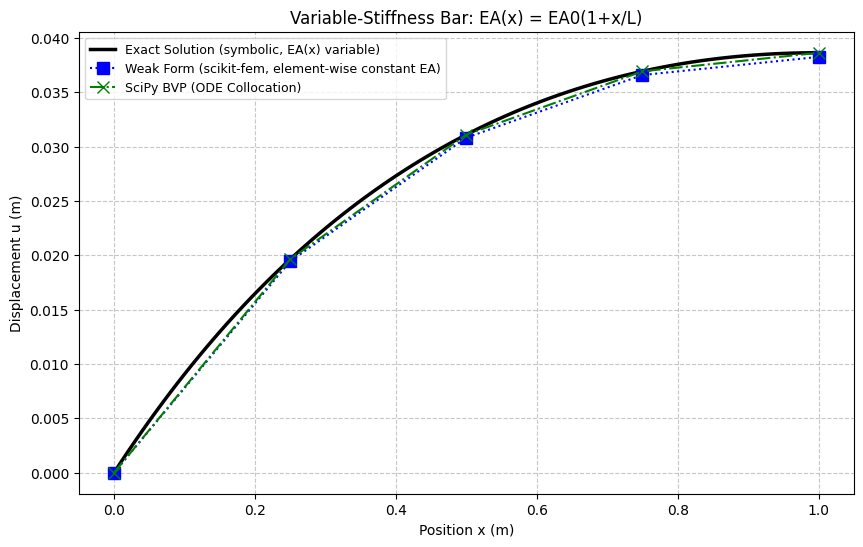

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(x_fine, u_exact_vals, 'k-', linewidth=2.5, label='Exact Solution (symbolic, EA(x) variable)')
plt.plot(nodes, u_weak_var, 'bs:', markersize=8, label='Weak Form (scikit-fem, element-wise constant EA)')
plt.plot(nodes, u_scipy_var, 'gx-.', markersize=9, label='SciPy BVP (ODE Collocation)')
plt.title("Variable-Stiffness Bar: EA(x) = EA0(1+x/L)", fontsize=12)
plt.xlabel("Position x (m)")
plt.ylabel("Displacement u (m)")
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

## 8. 觀察:節點精確性不見了

跟第 1 週的誤差表(機器精度,約 $10^{-16}$)比較,這次 `Weak Form vs 解析解` 的最大節點誤差
應該是有限但非零的值(通常落在 $10^{-3}\sim10^{-4}$ 量級,取決於元素數量)——**這是預期中的正常誤差,
不是程式碼錯誤**。

原因:第 1 週節點精確性成立的關鍵前提是「$EA$ 為常數」,此時線性元素恰好能讓加勒金解在節點上
與解析解的差(誤差函數)在能量範數下與有限元素空間正交,且這個正交性剛好在節點上給出零誤差
(這是一維常係數問題的特例)。一旦 $EA(x)$ 變化,這個特例條件被破壞,線性元素只能分段線性逼近
一個更複雜的解析解形狀,節點誤差不再精確為零——但仍然會隨著元素數量增加而收斂到零
(這是第 3-4 週要正式討論的收斂率問題)。

`SciPy BVP` 通常會比 `Weak Form` 更接近解析解,因為它用的是自適應網格加密的搭配法,
而 `Weak Form` 這裡刻意只用了粗糙的 4 個等分元素,且用元素中點值近似 $EA(x)$——
這本身也是一個值得注意的建模簡化(材料性質在元素內被離散化為分段常數),
會在第 3-4 週更仔細討論。

## 9. 討論題(課堂/作業)

1. 把 `n_elements` 從 4 逐步增加到 8、16、32,畫出 `Weak Form vs 解析解` 最大節點誤差
   隨元素數量變化的圖(建議用 log-log 座標)。誤差下降的斜率大概是多少?這個斜率有沒有
   讓你聯想到某種「收斂階數」?(這是第 3-4 週的預告)
2. 本週推導假設 $EA(x)$ 連續可微。如果桿件是兩段不同材料黏接而成
   (即 $EA(x)$ 在某一點 $x_0$ 處**不連續**,例如左半段 $EA=100$、右半段 $EA=50$),
   強形式在 $x_0$ 處的 $u''$ 還有意義嗎?弱形式呢?試著修改本週程式碼跑一次這個案例。
3. 第 3 節推導自然邊界條件時,我們用的是自由端 $EA(L)u'(L)=0$。如果改成右端也是固定端
   (兩端都是 Dirichlet 邊界條件),測試函數空間 $V_0$ 該怎麼修改?這種情況下還有「自然邊界條件」
   這件事嗎?
4. 回頭檢查第 1 週 `pyFEM`(手算)那個 cell,它的高斯積分點與權重是寫死的常數
   (`gauss_pts = [-1/√3, 1/√3]`)。如果要處理本週的變係數 $EA(x)$,這段程式碼需要怎麼修改?
   動手改一次,驗證你改完的手算結果是否也收斂到本週的符號解析解。

## 下週預告

第 3 週會正式回到「手算」路線,但這次目標是**理解收斂率本身**:固定問題不變,
系統性地改變元素數量與元素階數(線性 vs 二次元素),量化觀察誤差如何隨網格加密而下降,
並用今天符號積分得到的變係數解析解作為收斂率分析的基準解。